# 📊 Auto-Regressive (AR) Model - Reliance Stock

## Objective
To implement an Auto-Regressive (AR) model on stock price data to predict future values based on past observations.

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [33]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.ar_model import AutoReg
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [34]:
df=pd.read_csv("Reliance.csv")
df

,Date,Open,High,Low,Close,Adj Close,Volume
0,2015-11-18,463.799988,465.649994,454.975006,456.000000,436.671021,5142766.0
1,2015-11-19,459.450012,469.350006,458.625000,467.375000,447.563873,5569752.0
2,2015-11-20,467.000000,476.399994,462.774994,473.424988,453.357422,5167930.0
3,2015-11-23,475.000000,478.950012,473.100006,476.875000,456.661224,4800026.0
4,2015-11-24,476.500000,485.799988,475.524994,483.850006,463.340515,6768886.0
...,...,...,...,...,...,...,...
1228,2020-11-10,2077.000000,2090.000000,2041.199951,2084.550049,2084.550049,17045147.0
1229,2020-11-11,2089.000000,2095.000000,1978.099976,1997.199951,1997.199951,26178477.0
1230,2020-11-12,1981.000000,2008.449951,1965.000000,1980.000000,1980.000000,18481466.0
1231,2020-11-13,1982.000000,2036.650024,1981.750000,1996.400024,1996.400024,20946864.0


In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1233 entries, 0 to 1232
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1233 non-null   object 
 1   Open       1232 non-null   float64
 2   High       1232 non-null   float64
 3   Low        1232 non-null   float64
 4   Close      1232 non-null   float64
 5   Adj Close  1232 non-null   float64
 6   Volume     1232 non-null   float64
dtypes: float64(6), object(1)
memory usage: 67.6+ KB


In [36]:
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,1232.000000,1232.000000,1232.000000,1232.000000,1232.000000,1.232000e+03
mean,1036.035414,1048.479285,1023.015573,1035.164502,1024.471417,9.981743e+06
std,463.719976,469.906022,455.946191,462.301697,466.231636,7.603435e+06
min,459.000000,465.649994,444.049988,453.274994,434.061554,1.283997e+06
25%,551.925003,561.393768,546.000000,553.049988,540.720703,5.555522e+06
50%,959.099976,972.474976,946.675018,960.949982,946.843903,7.560520e+06
75%,1309.024963,1321.649963,1292.274963,1308.337494,1298.972321,1.140781e+07
max,2325.000000,2369.350098,2310.550049,2324.550049,2324.550049,6.523004e+07


In [37]:
df.isnull().sum()

Date         0
Open         1
High         1
Low          1
Close        1
Adj Close    1
Volume       1
dtype: int64

In [38]:
df.fillna(method='bfill' , inplace=True)

C:\Users\TEJASVINI\AppData\Local\Temp\ipykernel_290488\592715458.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df.fillna(method='bfill' , inplace=True)


In [39]:
df.isnull().sum()

Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

In [40]:
df["Date"] = pd.to_datetime(df["Date"])
df.set_index("Date", inplace=True)

# Use closing price for time series
data = df['Close']

In [41]:
result = adfuller(df["Close"])
print(f"ADF statistic = {result[0]:.2f}, p-value = {result[1]:.2f}")

ADF statistic = -0.29, p-value = 0.93


In [42]:
df_diff = df["Close"].diff().dropna()

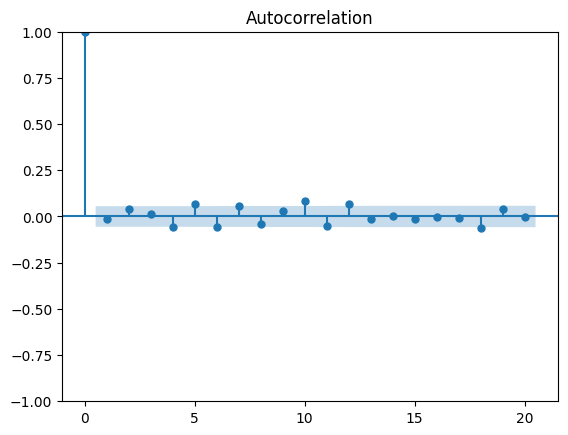

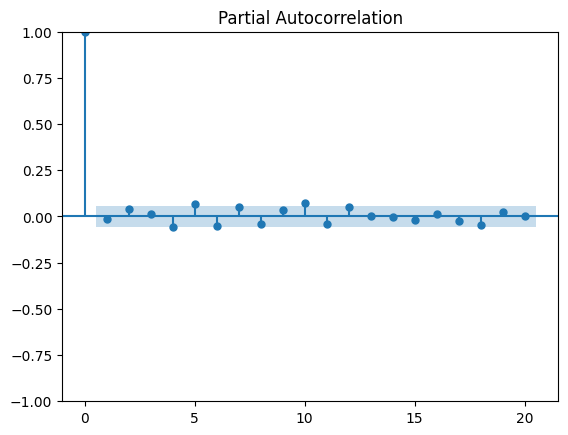

In [43]:
#These plots help identify patterns and dependencies in time series data:

plot_acf(df_diff, lags=20)
plot_pacf(df_diff, lags=20)
plt.show()

In [44]:
#Splits data into:
#80% training data
#20% testing data:

n = len(df_diff)
train_end = int(n*0.8)
train,test = df_diff.iloc[:train_end], df_diff.iloc[train_end:]

In [45]:
#Builds and trains an AR(4) model using past 4 values to predict future values:

p = 4
model = AutoReg(train, lags=p)
model_fit = model.fit()
print(model_fit.summary())

                            AutoReg Model Results                             
Dep. Variable:                  Close   No. Observations:                  985
Model:                     AutoReg(4)   Log Likelihood               -4061.568
Method:               Conditional MLE   S.D. of innovations             15.200
Date:                Wed, 06 May 2026   AIC                           8135.136
Time:                        15:00:49   BIC                           8164.467
Sample:                             4   HQIC                          8146.294
                                  985                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          1.0114      0.489      2.067      0.039       0.052       1.970
Close.L1       0.0613      0.032      1.920      0.055      -0.001       0.124
Close.L2       0.0797      0.032      2.487      0.0

C:\Users\TEJASVINI\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


In [46]:
pred_train = model_fit.predict(start=p, end=len(train)-1, dynamic=False)
pred_test = model_fit.predict(start=len(train), end=len(df_diff)-1, dynamic=False)

C:\Users\TEJASVINI\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
C:\Users\TEJASVINI\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
C:\Users\TEJASVINI\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\tsa\deterministic.py:308: UserWarning: Only PeriodIndexes, DatetimeIndexes with a frequency set, RangesIndexes, and Index with a unit increment support extending. The index is set will contain the position relative to the data length.
  fcast_index = self._extend_index(index, steps, forecast_index)


In [47]:
rmse = np.sqrt(mean_squared_error(test, pred_test))
mae = mean_absolute_error(test, pred_test)
print(rmse, mae)

42.12814562161684 29.61558770322407


In [48]:
last_train_value = df["Close"].iloc[train_end]
forecast_orig = pred_test.cumsum() + last_train_value
forecast_orig.index = test.index

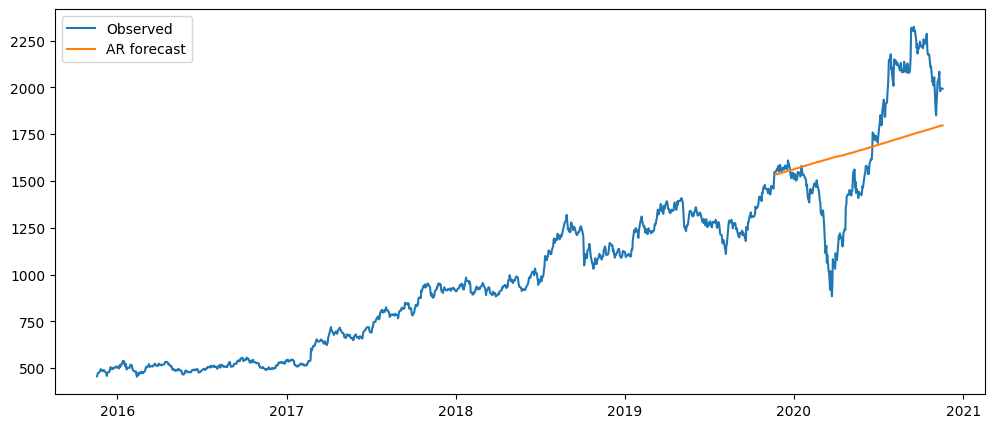

In [49]:
plt.figure(figsize=(12,5))
plt.plot(df["Close"], label="Observed")
plt.plot(forecast_orig, label="AR forecast")
plt.legend()
plt.show()

### 🔹 Observations

- AR model uses past values to predict future values  
- Predictions follow the trend but may lag behind actual values  
- Model performance depends on lag selection  

## ✅ Conclusion

The Auto-Regressive model is useful for time series forecasting.  
It captures patterns from past observations to predict future stock prices.